In [9]:
import os
import joblib
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [10]:
# --------------------------------------------------------
# Cargar archivo de test (asegúrate de separar X_test y y_test)
# --------------------------------------------------------
df_test = pd.read_csv("datos/Datos_Train-Validation.csv")

# Suponiendo que la columna objetivo se llama "target"
X_test = df_test.drop('Exited', axis=1)
y_test = df_test["Exited"]

In [11]:

# --------------------------------------------------------
# Carpeta donde tienes los modelos .joblib
# --------------------------------------------------------
ruta_modelos = "modelos"

# Obtener lista de archivos .joblib
model_files = [f for f in os.listdir(ruta_modelos) if f.endswith(".joblib")]

print("Modelos encontrados:", model_files)


Modelos encontrados: ['modelo_RF_tunned_Semilla.joblib', 'modelo_MLP_tunned.joblib']


In [12]:
df_test1 = pd.read_csv("datos/Datos_Test_X.csv")

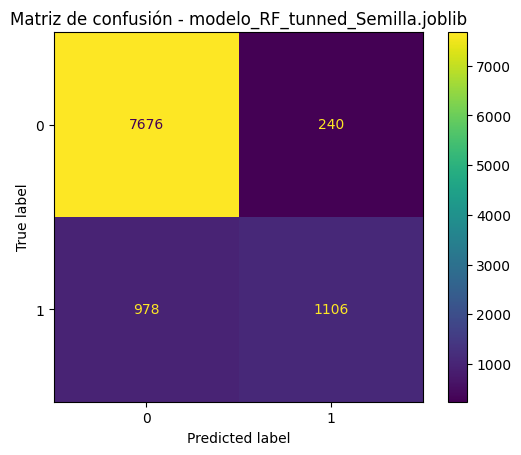

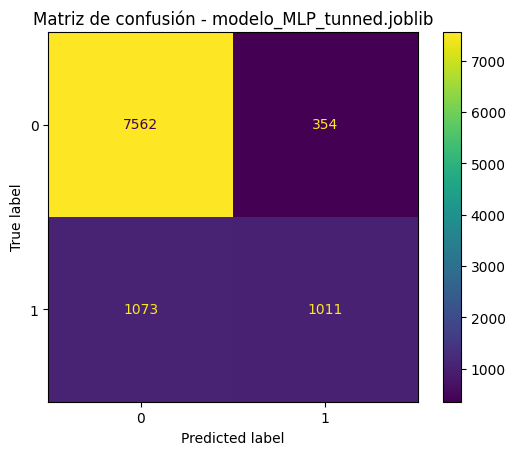

In [13]:
# --------------------------------------------------------
# Probar cada modelo y graficar su matriz de confusión
# --------------------------------------------------------
for model_file in model_files:
    ruta = os.path.join(ruta_modelos, model_file)

    # Cargar modelo
    modelo = joblib.load(ruta)

    # Predicciones
    pred = modelo.predict(X_test)
    pred1 = modelo.predict(df_test1)
    pd.DataFrame(pred1, columns=["Predicciones"]).to_csv(f"predicciones_{model_file}_JoseAque.csv", index=False)
    # pd.DataFrame(pred, columns=["Predicciones"]).to_csv(f"predicciones_{model_file}_JoseAque.csv", index=False)


    # Matriz de confusión
    cm = confusion_matrix(y_test, pred, labels=modelo.classes_)

    # Mostrar
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    disp.plot()
    plt.title(f"Matriz de confusión - {model_file}")
    plt.show()

    # 38